Vaccination Project


Step 1: Loading the data

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [10]:
sns.set_theme(style ="whitegrid")

df_raw = pd.read_csv(r"MCV1.csv")
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (195, 23)


,Country,2021,2020,2019,2018,2017,2016,2015,2014,2013,...,2009,2008,2007,2006,2005,2004,2003,2002,2001,2000
0,Afghanistan,63,66,64,71,67,64,62,60,57,...,60.0,59.0,55.0,53.0,50.0,48.0,39.0,35.0,37.0,27.0
1,Albania,87,91,95,94,96,96,97,98,99,...,97.0,98.0,97.0,95.0,97.0,96.0,93.0,96.0,95.0,95.0
2,Algeria,80,80,80,80,88,94,95,95,95,...,92.0,88.0,92.0,91.0,83.0,81.0,84.0,81.0,83.0,80.0
3,Andorra,99,98,99,99,99,97,96,96,95,...,98.0,98.0,94.0,91.0,94.0,98.0,96.0,98.0,97.0,97.0
4,Angola,36,44,51,50,42,45,51,56,59,...,46.0,48.0,58.0,21.0,21.0,43.0,44.0,59.0,60.0,32.0


Step 2: Reshaping dataset into "long" format


In [11]:
df_long = df_raw.melt(id_vars="Country", var_name="Year", value_name = "Coverage")
df_long["Year"] = df_long["Year"].astype(int)

print("Shape:", df_long.shape)
df_long.head(10)

Shape: (4290, 3)


,Country,Year,Coverage
0,Afghanistan,2021,63.0
1,Albania,2021,87.0
2,Algeria,2021,80.0
3,Andorra,2021,99.0
4,Angola,2021,36.0
5,Antigua and Barbuda,2021,85.0
6,Argentina,2021,81.0
7,Armenia,2021,94.0
8,Australia,2021,93.0
9,Austria,2021,95.0


Step 3: Checking data quality

In [12]:
print("Missing values:", df_long["Coverage"].isna().sum())
print("Min coverage:", df_long["Coverage"].min())
print("Max coverage:", df_long["Coverage"].max())
print("Unique countries:", df_long["Country"].nunique())
print("Year range:", df_long["Year"].min(), "-", df_long["Year"].max())

Missing values: 19
Min coverage: 8.0
Max coverage: 99.0
Unique countries: 195
Year range: 2000 - 2021


In [13]:
# Where exactly are the missing values?
missing = df_long[df_long["Coverage"].isna()]
print(missing["Country"].value_counts())
print()
print(missing["Year"].value_counts().sort_index())

Country
South Sudan    11
Montenegro      6
Timor-Leste     2
Name: count, dtype: int64

Year
2000    3
2001    3
2002    2
2003    2
2004    2
2005    2
2006    1
2007    1
2008    1
2009    1
2010    1
Name: count, dtype: int64


19 missing values are identified. These missing values are due to the fact that 3 countries had not yet gained independence. 
These countries are: South Sudan, which gained independence in 2011 (11 missing years in the dataset), 
Montenegro Which became independent in 2006(6 missing years in the dataset) and 
Timor-Leste(2 missing years in the dataset) , which became indepent in 2002.

Step 4: First chart - global trend overtime

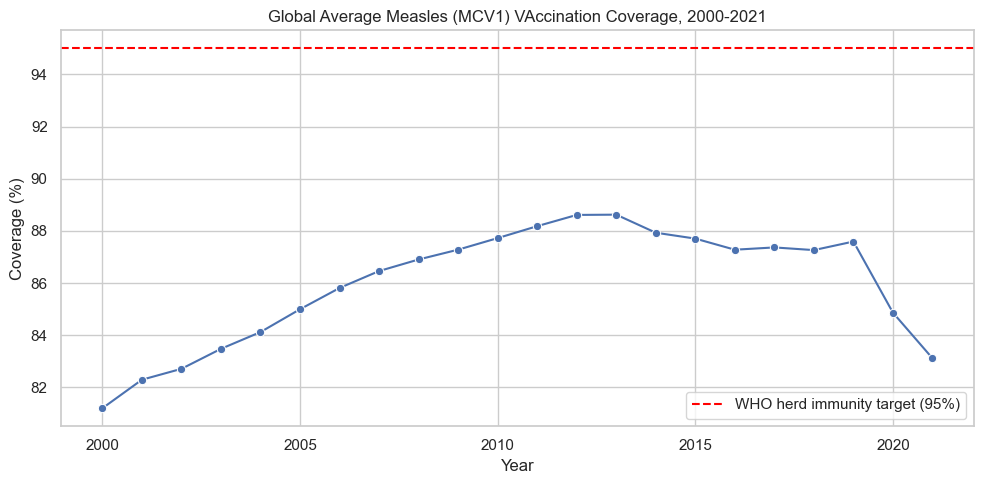

In [14]:
global_trend = df_long.groupby("Year")["Coverage"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=global_trend, x="Year", y="Coverage", marker = "o")
plt.axhline(95, color="red", linestyle="--", label = "WHO herd immunity target (95%)")
plt.title("Global Average Measles (MCV1) VAccination Coverage, 2000-2021")
plt.ylabel("Coverage (%)")
plt.legend()
plt.tight_layout()
plt.show()

We started with this chart because we want to know "In general, is the world getting better or worse at this?"

We want the big picture first.
Before zooming into specific countries.

`Herd immunity` - when enough people in a population are immune to a disease, usually through vaccination, the disease struggles to spread from person to person, even to the people who aren't immune.

Measeles is extremely contagious; one infected person can infect 12-18 others in a vulnerable population.
Because it spreads easily, the percentage of the population immunity should be very high. Hence choosing 95% as the benchmark. Below that threshhold, even a few unvaccinated people can spark outbreaks that spread quickly.



Step 5: Finding at - risk countries(lowest coverage, latest year)

In [15]:
# Focusing on the most recent year available
latest_year = df_long["Year"].max()
latest = df_long[df_long["Year"] == latest_year].dropna(subset = ["Coverage"])

# Sort to find the countries with the lowest coveerage
at_risk = latest.sort_values("Coverage").head(15)

print(f"Most recent year: {latest_year}")
print(at_risk[["Country", "Coverage"]])

Most recent year: 2021
                                   Country  Coverage
114                             Montenegro      18.0
4                                   Angola      36.0
133                       Papua New Guinea      38.0
101                             Madagascar      39.0
32                Central African Republic      41.0
46   Democratic People's Republic of Korea      42.0
117                                Myanmar      44.0
161                                Somalia      46.0
71                                  Guinea      47.0
163                            South Sudan      49.0
189                                Vanuatu      50.0
49                                Djibouti      50.0
55                       Equatorial Guinea      53.0
59                                Ethiopia      54.0
47        Democratic Republic of the Congo      55.0


Step 6: Investigating  if the coverage for Montenegro (18) is an outlier

In [16]:
montenegro = df_long[df_long["Country"] == "Montenegro"].sort_values("Year")
print(montenegro[["Year", "Coverage"]].to_string(index=False))

 Year  Coverage
 2000       NaN
 2001       NaN
 2002       NaN
 2003       NaN
 2004       NaN
 2005       NaN
 2006      90.0
 2007      90.0
 2008      89.0
 2009      86.0
 2010      90.0
 2011      91.0
 2012      90.0
 2013      88.0
 2014      76.0
 2015      64.0
 2016      47.0
 2017      58.0
 2018      42.0
 2019      33.0
 2020      24.0
 2021      18.0


Montenegro sat at a healthy 86-91% from 2006 to 2013. Then began a steep, steady decline starting around 2014, dropping almost every single year down to 18% by 2021. This isn't a glitch - it's a genuine, sustained collapse in measles vaccination over roughly a decade.

I did further research and found out that: 
It's not only measles vaccinations that dropped, but also mumps and rubella(MMR).
This is due to intense vaccine hesitancy fuelled by unverified safety fears, a loss of public trust in health institutions and the compounding strain on routine healthcare services.


Step 7: Charting Montenegro's decline

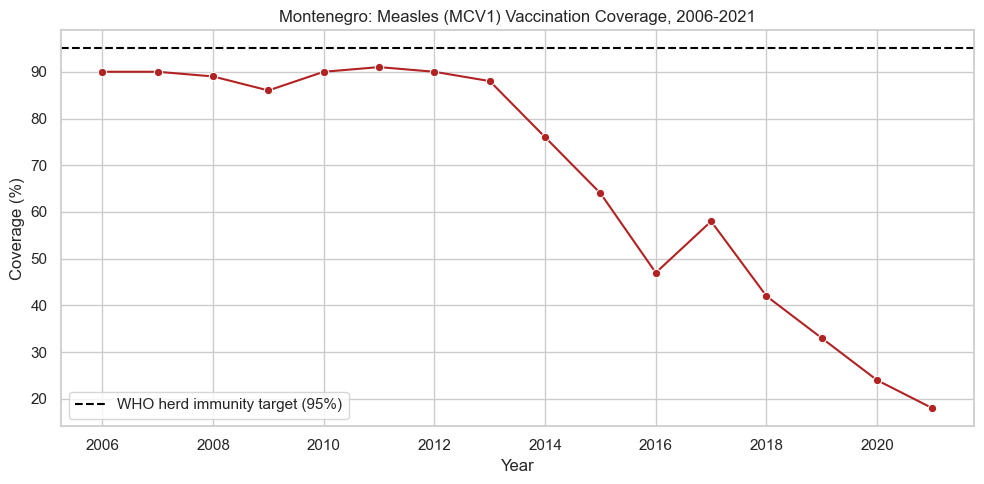

In [17]:
montenegro = df_long[df_long["Country"] == "Montenegro"].sort_values("Year")

plt.figure(figsize=(10, 5))
sns.lineplot(data=montenegro, x = "Year", y = "Coverage", marker = "o", color = "firebrick")
plt.axhline(95, color = "black", linestyle = "--", label = "WHO herd immunity target (95%)")
plt.title("Montenegro: Measles (MCV1) Vaccination Coverage, 2006-2021")
plt.ylabel("Coverage (%)")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()

This chart clearly shows the drop in vaccination coverage starting from the year 2013. With a slight increase in coverage in the year 2017. About a 58% recovery, but it continued to fall linearly since then.

From https://cdn.who.int/media/docs/default-source/country-profiles/immunization/2024-country-profiles/immunization-2024-mne.pdf?sfvrsn=ea99d65b_3&download=true


We see that the coverage vaccination for MCV1 drops as the years go by. this is due to rising of vaccinne hesitancy caused by unverified safety concerns  and eroding public trust in health institutions.
A pattern also seen across MMR vaccines broadly, not just measles.

Step 8: Checking a few more at-risk countries

In [18]:
countries_to_check = ["Angola", "Papua New Guinea", "Central African Republic","Democratic People's Republic of Korea"]

for country in countries_to_check:
    data = df_long[df_long["Country"] == country].sort_values("Year")
    print(f"\n{country}:")
    print(data[["Year", "Coverage"]].to_string(index=False))


Angola:
 Year  Coverage
 2000      32.0
 2001      60.0
 2002      59.0
 2003      44.0
 2004      43.0
 2005      21.0
 2006      21.0
 2007      58.0
 2008      48.0
 2009      46.0
 2010      62.0
 2011      57.0
 2012      65.0
 2013      59.0
 2014      56.0
 2015      51.0
 2016      45.0
 2017      42.0
 2018      50.0
 2019      51.0
 2020      44.0
 2021      36.0

Papua New Guinea:
 Year  Coverage
 2000      69.0
 2001      65.0
 2002      73.0
 2003      77.0
 2004      77.0
 2005      82.0
 2006      82.0
 2007      72.0
 2008      66.0
 2009      65.0
 2010      63.0
 2011      66.0
 2012      71.0
 2013      72.0
 2014      65.0
 2015      57.0
 2016      46.0
 2017      38.0
 2018      37.0
 2019      37.0
 2020      47.0
 2021      38.0

Central African Republic:
 Year  Coverage
 2000      36.0
 2001      35.0
 2002      42.0
 2003      49.0
 2004      55.0
 2005      62.0
 2006      61.0
 2007      59.0
 2008      58.0
 2009      56.0
 2010      53.0
 2011      49.0
 

The visuals

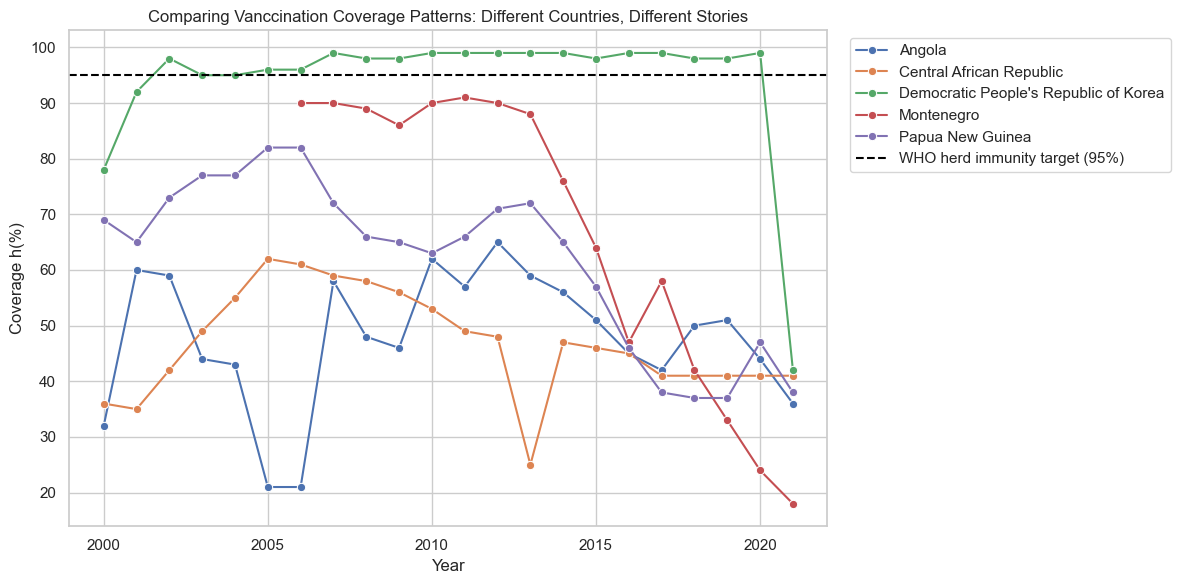

In [19]:
countries_to_check = ["Angola", "Papua New Guinea", "Central African Republic","Democratic People's Republic of Korea", "Montenegro"]

comparison_data = df_long[df_long["Country"].isin(countries_to_check)]

plt.figure(figsize = (12,6))
sns.lineplot(data = comparison_data, x = "Year", y = "Coverage", hue = "Country", marker = "o")
plt.axhline(95, color="black", linestyle = "--", label = "WHO herd immunity target (95%)")
plt.title("Comparing Vanccination Coverage Patterns: Different Countries, Different Stories")
plt.ylabel("Coverage h(%)")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.02, 1), loc = "upper left")
plt.tight_layout()
plt.show()

For North Korea(green), the drastic drop in `MCV1` vaccination coverage from 2020 was due to the COVID -19 pandemic. Extreme, prolonged border closures and stringent lockdowns implemented during COVID-19 pandemic caused this.

Angola(blue) and Papua New Guinea(purple) both bounce around chaotically in the 40-80% range for 20 years, never approaching the target, never fully collapsing either. A totally different shape from the other two

Central African Republic(orange) - Shows a rougher downward drift with a sharp one year dip in 2013. This was caused primarily by severe civil unrest and political instability which led to the widespread collapse and interruption of basic health services and large-scale population displacement.

Step 9: Getting Kenya's data

In [20]:
kenya = df_long[df_long["Country"] == "Kenya"].sort_values("Year")
print(kenya[["Year", "Coverage"]].to_string(index=False))

 Year  Coverage
 2000      78.0
 2001      77.0
 2002      78.0
 2003      72.0
 2004      73.0
 2005      69.0
 2006      77.0
 2007      80.0
 2008      90.0
 2009      88.0
 2010      86.0
 2011      87.0
 2012      93.0
 2013      94.0
 2014      95.0
 2015      96.0
 2016      96.0
 2017      89.0
 2018      89.0
 2019      89.0
 2020      88.0
 2021      89.0


Step 10: Plotting Kenya's data

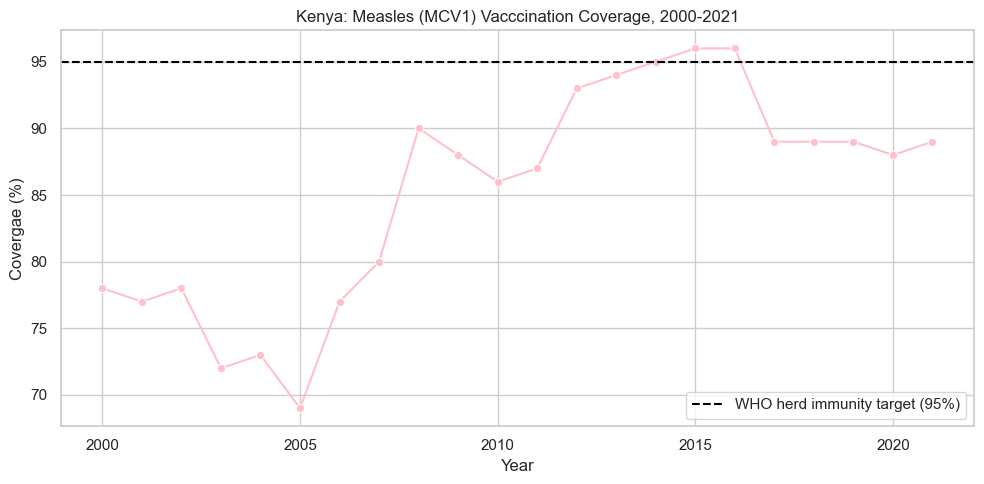

In [21]:
plt.figure(figsize=(10,5))
sns.lineplot(data=kenya, x="Year", y="Coverage", marker ="o",color = "pink")
plt.axhline(95, color ="black", linestyle = "--", label = "WHO herd immunity target (95%)")
plt.title("Kenya: Measles (MCV1) Vacccination Coverage, 2000-2021")
plt.ylabel("Covergae (%)")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
plt.show()

Unlike Montenegro's collapse or Angola/PNG's volatility, Kenya shows a genuine long-term improvement story. Coverage rose steadily from 69%(2005) to a peak of 96%(2015-2016), briefly achieving the WHO herd immunity target. A modest decline followed(dropping to around 88-89% by 2017 onward),but coverage hss remained relatively stable since, well above where it started in 2000-2005

I did further research and found out that:The severe drop in coverage in 2005 was caused by the postponement of a critical nation wide mass vaccination campaign.Health authorities chose to delay the campaign to 2006 so they could combine it with the nationwide distribution of long-lasting insecticide-treated bednets (LLINs). This delay left a large cohort of infants vulnerable and led to an immediate decline in overall coverage numbers.

Step 11: Checking whether a COVID-era dip(2020-2021) shows up broadly across all 195 countries

In [22]:
before = df_long[df_long["Year"] == 2019][["Country", "Coverage"]].rename(columns ={"Coverage": "Coverage_2019"})
after = df_long[df_long["Year"] == 2021][["Country", "Coverage"]].rename(columns = {"Coverage": "Coverage_2021"})

covid_compare = before.merge(after, on = "Country")
covid_compare["Change"] = covid_compare["Coverage_2021"] - covid_compare["Coverage_2019"]

print("How many countries dropped vs improved:")
print((covid_compare["Change"] < 0).sum(), "countries declined")
print((covid_compare["Change"] > 0).sum(), "countries improved")
print((covid_compare["Change"] == 0).sum(), "countries unchanged")

print("\n10 countries with the biggest drops:")
print(covid_compare.sort_values("Change").head(10)[["Country", "Coverage_2019", "Coverage_2021", "Change"]].to_string(index = False))

How many countries dropped vs improved:
113 countries declined
24 countries improved
58 countries unchanged

10 countries with the biggest drops:
                              Country  Coverage_2019  Coverage_2021  Change
Democratic People's Republic of Korea           98.0           42.0   -56.0
                              Myanmar           84.0           44.0   -40.0
                                Samoa           96.0           62.0   -34.0
                             Djibouti           83.0           50.0   -33.0
                              Vanuatu           80.0           50.0   -30.0
   Venezuela (Bolivarian Republic of)           93.0           68.0   -25.0
                            Mauritius           99.0           77.0   -22.0
                             Paraguay           87.0           68.0   -19.0
                          Saint Lucia           96.0           77.0   -19.0
                               Brazil           91.0           73.0   -18.0


Findings on step 11
COVID era impact was broad, not isolated:
Comparing 2019(pre-COVID) to 2021 across all 195 countries: 
113 countries(58%) saw measles coverage decline. Only 24 countries improved(12%) and 58 countries stayed unchanged. the average change across all countries was -4.48 percentage points; confirming this wasn't isolated to a few dramatic cases, but a genuine worldwide disruption to routine childhood immunization.

The countires hit hardest were geeographically and economically diverse. North Korea -> -56 percentage points,  extreme border lockdown. Myanmar -> -40pp, several small island nations(Samoa, Vanuatu, Saint Lucia), and even Brazil(-18pp), a large upper-middle-income country. 

This suggests the COVID era disruption affected health sysytems broadly, regardless of country size or income level, though North Korea's -56pp drop is an extreme outlier likely reflecting its unusually severe prolonged isolation policy rather than typical "COVID disruption"

For the countries that improved and remained unchanged they actively implemented catch-up campaigns, protected primary health infrastructure, and maintained strong local tracking rather than relying on passive recovery

Histogram on the above

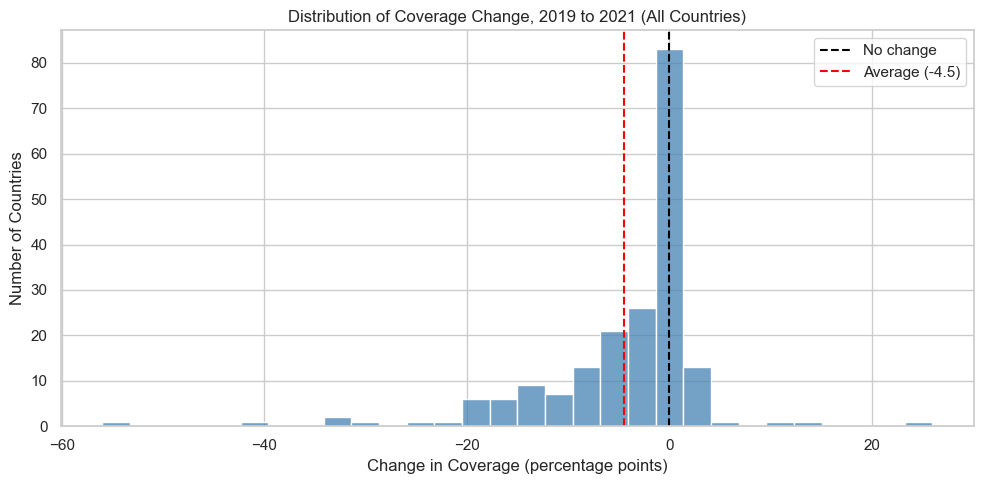

In [23]:
plt.figure(figsize=(10, 5))
sns.histplot(data = covid_compare, x = "Change", bins = 30, color = "steelblue")
plt.axvline(0, color = "black", linestyle = "--", label = "No change")
plt.axvline(covid_compare["Change"].mean(), color = "red", linestyle = "--", label = f"Average ({covid_compare['Change'].mean():.1f})")
plt.title("Distribution of Coverage Change, 2019 to 2021 (All Countries)")
plt.xlabel("Change in Coverage (percentage points)")
plt.ylabel("Number of Countries")
plt.legend()
plt.tight_layout()
plt.show()

The histogram reveals the COVID era impact wasn't evenly spread. Most countries clustered near "no change" while a smaller number of countries experienced severe, outlier-level declines(including North Korea at -56pp).

Mean and Median

In [24]:
print("Average change:", covid_compare["Change"].mean().round(2))
print("Median change:", covid_compare["Change"].median())

Average change: -4.48
Median change: -1.0


Average vs Median: The median change(-1.0pp) is far smaller than the average(-4.48pp), confirming the distribution is skewed by a small number of extreme cases rather than reflecting a uniformly severe global decline.

"I checked both mean and median, and found the average was skeweed by extreme outliers. So I made sure not to let one summary number tell a misleading story."

"Which countries make up that severe tail?"

In [25]:
severe_decline = covid_compare[covid_compare["Change"] <= -15].sort_values("Change")
print(f"{len(severe_decline)}countries had a severe decline (15+ percentage points):\n")
print(severe_decline[["Country", "Coverage_2019", "Coverage_2021", "Change"]].to_string(index=False))

23countries had a severe decline (15+ percentage points):

                              Country  Coverage_2019  Coverage_2021  Change
Democratic People's Republic of Korea           98.0           42.0   -56.0
                              Myanmar           84.0           44.0   -40.0
                                Samoa           96.0           62.0   -34.0
                             Djibouti           83.0           50.0   -33.0
                              Vanuatu           80.0           50.0   -30.0
   Venezuela (Bolivarian Republic of)           93.0           68.0   -25.0
                            Mauritius           99.0           77.0   -22.0
                             Paraguay           87.0           68.0   -19.0
                          Saint Lucia           96.0           77.0   -19.0
                               Brazil           91.0           73.0   -18.0
                          Philippines           75.0           57.0   -18.0
                Sao Tome and 

This group of severely hit countries is diverse. It includes small island nations(Samoa,Vanuatu,Saint Lucia, Barbados), Latin American countries (Brazil, Ecuador, Paraguay, Venezuela), Southeast Asian countries(Maynmar, Philippines, Indonesia) and even countires with historically strong health systems(Mauritius, Panama).

This challenges a simple  narrative; "COVID hit poor countries hardest" as several countries listed started from very high baselines(95% +) before dropping. Suggesting the disruption to routine healthcare delivery and supply chains affected countries across very different income levels and regions, not just the most vulnerable ones.

We can say that this severe drop in most countries was caused by fear-driven avoidance of health centres, severe transport restrictions, and the redirection of health workers toward pandemic response.

Step 12:





We are now working with world bank data to classify the countries well according to their income


In [26]:
income_df = pd.read_csv("world-bank-income-groups.csv")
print(income_df.shape)
income_df.head()


(8173, 4)


,entity,code,year,classification
0,Afghanistan,AFG,1987,Low-income countries
1,Afghanistan,AFG,1988,Low-income countries
2,Afghanistan,AFG,1989,Low-income countries
3,Afghanistan,AFG,1990,Low-income countries
4,Afghanistan,AFG,1991,Low-income countries


Step 13: Getting each country's most recent income classification

In [27]:
latest_income = income_df.sort_values("year").groupby("entity").tail(1)
latest_income = latest_income[["entity", "classification"]].rename(columns={"entity": "Country"})

print(latest_income.head(10))

                    Country                 classification
7634                   USSR  Upper-middle-income countries
1930         Czechoslovakia  Upper-middle-income countries
8094             Yugoslavia  Upper-middle-income countries
6572  Serbia and Montenegro  Lower-middle-income countries
5278   Netherlands Antilles          High-income countries
4814                Mayotte  Upper-middle-income countries
74                  Albania  Upper-middle-income countries
113                 Algeria  Upper-middle-income countries
152          American Samoa          High-income countries
188                 Andorra          High-income countries


Step 14: Merge it onto the COVID  comparison table.

In [28]:
merged = covid_compare.merge(latest_income, on = "Country", how = "left")

print(merged["classification"].isna().sum(), "countries couldn't be matched")
print(merged[merged["classification"].isna()]["Country"].tolist())


23 countries couldn't be matched
['Bolivia (Plurinational State of)', 'Brunei Darussalam', 'Cabo Verde', 'Cook Islands', "Côte d'Ivoire", "Democratic People's Republic of Korea", 'Democratic Republic of the Congo', 'Iran (Islamic Republic of)', "Lao People's Democratic Republic", 'Micronesia (Federated States of)', 'Niue', 'occupied Palestinian territory, including east Jerusalem', 'Republic of Korea', 'Republic of Moldova', 'Russian Federation', 'Syrian Arab Republic', 'Timor-Leste', 'Türkiye', 'United Kingdom of Great Britain and Northern Ireland', 'United Republic of Tanzania', 'United States of America', 'Venezuela (Bolivarian Republic of)', 'Viet Nam']


Step 15: Fixing the mismatches with a name-mapping dictionary

In [29]:
name_fixes = {
    "Bolivia (Plurinational State of)": "Bolivia",
    "Brunei Darussalam": "Brunei",
    "Cabo Verde": "Cape Verde",
    "Côte d'Ivoire": "Cote d'Ivoire",
    "Democratic People's Republic of Korea": "North Korea",
    "Democratic Republic of the Congo": "Democratic Republic of Congo",
    "Iran (Islamic Republic of)": "Iran",
    "Lao People's Democratic Republic": "Laos",
    "Micronesia (Federated States of)": "Micronesia (country)",
    "Republic of Korea": "South Korea",
    "Republic of Moldova": "Moldova",
    "Russian Federation": "Russia",
    "Syrian Arab Republic": "Syria",
    "Timor-Leste": "East Timor",
    "Türkiye": "Turkey",
    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",
    "United Republic of Tanzania": "Tanzania",
    "United States of America": "United States",
    "Venezuela (Bolivarian Republic of)": "Venezuela",
    "Viet Nam": "Vietnam",
}

covid_compare["Country_clean"] = covid_compare["Country"].replace(name_fixes)

merged = covid_compare.merge(latest_income, left_on="Country_clean", right_on="Country", how="left", suffixes=("", "_income"))

print(merged["classification"].isna().sum(), "countries still unmatched")
print(merged[merged["classification"].isna()]["Country"].tolist())

3 countries still unmatched
['Cook Islands', 'Niue', 'occupied Palestinian territory, including east Jerusalem']


Step 15 Findings - Data merge: Successfully merged income classification for 192/195 countries(98.5%). The 3 unmatched cases (Cook Islands, Niue, Palestine) are special.
Their political/territorial statuses are not consistently classified by the World Bank, and were left unmatched rather than force-fitted.

Step 16: Does income group predict servere decline in vaccination coverage?

In [30]:
# Average change by income group
income_summary = merged.groupby("classification")["Change"].agg(["mean", "median","count"])
print(income_summary)

print("\nSevere decline countries by income group:")
severe = merged[merged["Change"] <= -15]
print(severe["classification"].value_counts())

                                   mean  median  count
classification                                        
High-income countries         -1.730159     0.0     63
Low-income countries          -5.360000    -2.0     25
Lower-middle-income countries -6.456522    -3.0     46
Upper-middle-income countries -5.724138    -4.0     58

Severe decline countries by income group:
classification
Upper-middle-income countries    10
Lower-middle-income countries     8
Low-income countries              3
High-income countries             2
Name: count, dtype: int64


Step 16 Findings:
Relationship between income group and COVID-era decline:
High income countries were the least affected on average withe a mean of -1.7pp, and median 0;essentially unchanged. While the other 3 income groups all saw noticeably larger average declines(-5.4 to -6.5pp), with no clear step by step pattern between low,lower-middle, and upper-middle income. Lower-middle actually had the worst average but it's not the poorest group.

Looking at severe decline cases specifically: 20 of 23 severe decline countries(87%) came from low, lower-middle, or upper-middle income groups, while only 2 were high-income.
But notably, being high-income did not guarantee safety; 2 high-income countries (Panama, Mauritius) still suffered severe drops, and one full income group (upper-middle) actually had the most severe cases(10) despite not being the poorest group.


Conclusion: Income level is a meaningful factor. High-income countries were clearly more resilient on average, but it's not a clean predictor. The relationship is real but not deterministic, and a country's income level alone does not fully explain who suffered severe declines

Bar chart representing the above data

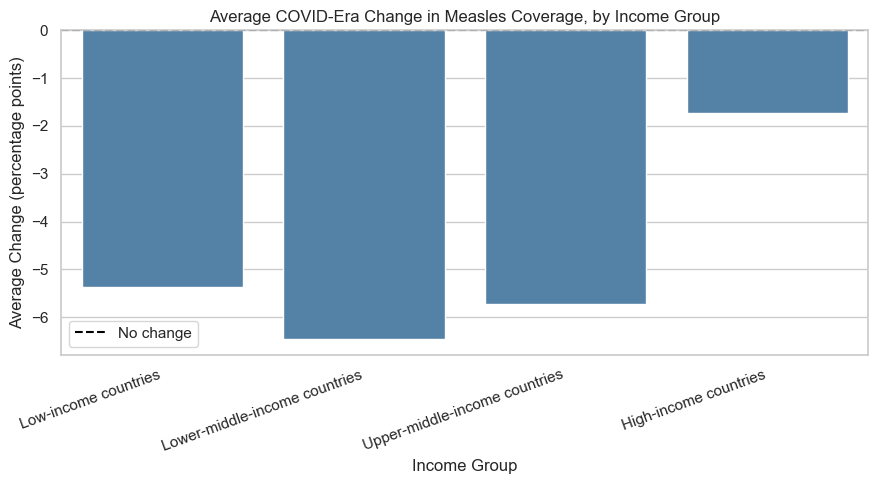

In [31]:
plt.figure(figsize=(9,5))
income_order = ["Low-income countries", "Lower-middle-income countries", "Upper-middle-income countries", "High-income countries"]
sns.barplot(data=merged, x = "classification", y="Change", order = income_order, color="steelblue", errorbar = None)
plt.axhline(0, color="black", linestyle = "--", label="No change")
plt.title("Average COVID-Era Change in Measles Coverage, by Income Group")
plt.ylabel("Average Change (percentage points)")
plt.xlabel("Income Group")
plt.xticks(rotation = 20, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

From the bar chart, we can clearly see the what step 16 findngs really look like.

High-income countries were the most protected, but among the other 3 groups, income level did not cleanly predict how much a country was affected.

Step 17: Feature Engineering

In [32]:
pre_covid = df_long[df_long["Year"].between(2015,2019)]

features = pre_covid.groupby("Country")["Coverage"].agg(
    avg_coverage_2015_2019 = "mean",
    volatility_2015_2019 = "std"
).reset_index()

# Trend: simple slope of coverage over these 5 years
import numpy as np

def calc_trend(group):
    years = group["Year"].values
    coverage = group["Coverage"].values
    if len(years) < 2 or coverage.std() == 0:
        return 0
    slope = np.polyfit(years, coverage, 1)[0]
    return slope

trend = pre_covid.groupby("Country").apply(calc_trend, include_groups=False).reset_index()
trend.columns = ["Country", "trend_2015_2019"]

features = features.merge(trend, on="Country")
features = features.merge(covid_compare[["Country", "Coverage_2019","Change"]], on="Country")
features["severe_decline"] = (features["Change"] <= -15).astype(int)

print(features.shape)
features.head(10)

(195, 7)


,Country,avg_coverage_2015_2019,volatility_2015_2019,trend_2015_2019,Coverage_2019,Change,severe_decline
0,Afghanistan,65.6,3.507136,1.1,64.0,-1.0,0
1,Albania,95.6,1.140175,-0.6,95.0,-8.0,0
2,Algeria,87.4,7.266361,-4.4,80.0,0.0,0
3,Andorra,98.0,1.414214,0.8,99.0,0.0,0
4,Angola,47.8,4.086563,0.5,51.0,-15.0,1
5,Antigua and Barbuda,93.4,4.277850,1.2,93.0,-8.0,0
6,Argentina,89.6,2.880972,-0.2,86.0,-5.0,0
7,Armenia,96.0,1.000000,-0.6,95.0,-1.0,0
8,Australia,94.4,0.547723,-0.3,94.0,-1.0,0
9,Austria,95.2,0.836660,-0.3,95.0,0.0,0


Step 17: Feature Engineering:
I built a country-level feature table using only pre-COVID data(2015-2019) to avoid data leakage. Average coverage, year-to-year volatility(standard deviation), and trend(slope of coverage over time), alongside the 2019 snapshot value.

I took the dependent/target/y variable to be severe_decline.
(1 if a country's coverage dropped 15+ points from 2019 to 2021, 0 otherwise).

There is a confirmed class imbalance: only 23/193 countries (11.8%)are positive cases.
23 countries are the positive cases -> "YES there is a severe decline in these countries"
172 countries are the negative cases -> "NO there is no severe decline in these countries."

Step 18: Training/ Testing split

In [33]:
from sklearn.model_selection import train_test_split

feature_cols = ["avg_coverage_2015_2019", "volatility_2015_2019", "trend_2015_2019", "Coverage_2019"]
X = features[feature_cols]
y = features["severe_decline"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.25, stratify = y, random_state = 42
)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nSevere decline %  in training set:", y_train.mean().round(3))
print("Severe decline % in test set:", y_test.mean().round(3))

Training set size: 146
Test set size: 49

Severe decline %  in training set: 0.116
Severe decline % in test set: 0.122


Step 18 Explanation:
I split the 195 countries into; 146 for training and 49 for testing(75/25 split), using stratification to preserve the approximately 12% severe_decline rate in both sets.

This ensures the test set is fair, representative sample rather than accidentally over-representing or underepresenting severe cases.

Step 19: Train the model

I'll use logistic regression

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale features so they are on comparable ranges
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(class_weight = "balanced", random_state = 42)
model.fit(X_train_scaled,y_train)

print("Model trained successfully")


Model trained successfully


In [35]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_scaled)

In [36]:
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion matrix:
[[31 12]
 [ 5  1]]


In [37]:
print(classification_report(y_test, y_pred, target_names=["Not severe", "Severe decline"]))


                precision    recall  f1-score   support

    Not severe       0.86      0.72      0.78        43
Severe decline       0.08      0.17      0.11         6

      accuracy                           0.65        49
     macro avg       0.47      0.44      0.45        49
  weighted avg       0.77      0.65      0.70        49



In [38]:
print("Feature importance (coefficients):")
for feat, coef in zip(feature_cols, model.coef_[0]):
    print(f"  {feat}: {coef:.3f}")

Feature importance (coefficients):
  avg_coverage_2015_2019: -0.078
  volatility_2015_2019: 0.722
  trend_2015_2019: -0.076
  Coverage_2019: 0.480


Confusion matrix explanation:
Of the 43  countries that were actually fine, the model correctly identified 31 of them, but wrongly flagged 12 as "severe" when they were not.

Of the 6 countries that actually did have a severe decline, the model only caught 1 and completely missed the other 5.


Precision = 0.08: When the model says "this country is at severe risk," it's only right 8% of the time. So it's "alarm" is mostly false alarms.

Recall = 0.17: Of all the countries that actually did have a severe decline, the model only caught 17% of them. Meaning it misses 83% of the real cases.

Result: The model performed poorly

Conclusion:

I tested whether a country's own pre-COVID vaccination patterns could predict severe decline, and found they COULD NOT. Suggesting the disruption was driven more by external, unpredictable shocks(like specific lockdown policies or supply chain disruptions) than by any pre-existing weakness in a country's immunization system. 